In [1]:
import sys

from statsbombpy import sb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mplsoccer import VerticalPitch
import time
from tqdm import tqdm


sys.path.append("../")
from xThreat import xThreat

# Introduction

The goal of this notebook is to find what maximal error is acceptable. This is done by looking at the Euros 2020 data set that is openly available.
<br><br>
This data is used to obtain the action ratings by the Expected Threat model. The xT values are then distorded by adding noise with a maximal error. The maximal error for which less than 10% of all in-game players changes a quartile is found.

In [2]:
n_x = 16
n_y = 12

In [3]:
xT_true_16x12 = xThreat.load_from_pickle(f'../2-train-models/model-storage/true-models/xt-full-data-n_x{16}-n_y{12}.pickle')

In [4]:
# df_euros = pd.read_parquet('../1-data-preparation/data-storage/xThreat_data_v3_euros2020.parquet')

In [5]:
# df_euros.describe()

In [6]:
# df_euros.head()

## Get the Ligue 1 20215/2026 data

In [7]:
# Liguea 1 has competition_id = 7
competition_id = 7
# Season 2015/2016 has season_id = 27
season_id = 27

In [8]:
# Get the matches for Ligue 1 2015/2016
Ligue_1_season_1516 = sb.matches(competition_id=competition_id, season_id=season_id)

In [9]:
# Load the data
data_path = '../1-data-preparation/data-storage/xThreat_data_v3.parquet'
df_events = pd.read_parquet(data_path, engine='fastparquet')

# Filter for Ligue 1 2015/2016 matches
df_events = df_events[df_events['match_id'].isin(Ligue_1_season_1516['match_id'].tolist())]

# Create 'shot' and 'goal' columns to use for xThreat calculation
df_events['shot'] = ~df_events['shot_outcome'].isna()
df_events['goal'] = df_events['shot_outcome'] == 'Goal'

# Get rid of unnecessary columns to save memory
df_events.drop(columns=['id', 'shot_outcome', 'possession'], inplace=True)
df_size_bytes = df_events.memory_usage(deep=True).sum()
df_size_mb = df_size_bytes / (1024 ** 2)  # Convert to MB
print(f"DataFrame size: {df_size_mb:.2f} MB")

DataFrame size: 157.81 MB


In [10]:
df_events.head()

,x,y,possession_kept,possession_length,chain_length,previous_deleted,match_id,period,player_id,type,...,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id,shot,goal
index,,,,,,,,,,,,,,,,,,,,,
8,37.6250,34.085,True,0,0,True,3829413,1,3026.0,Pass,...,Ground Pass,NaN,Carry,26.0750,28.305,NaN,131.0,3956.0,False,False
1797,26.0750,28.305,True,1,1,False,3829413,1,3956.0,Carry,...,None,NaN,Pass,25.6375,30.260,NaN,131.0,3956.0,False,False
9,25.6375,30.260,True,2,2,False,3829413,1,3956.0,Pass,...,Ground Pass,NaN,Carry,24.2375,45.220,NaN,131.0,3295.0,False,False
1798,24.2375,45.220,True,3,3,False,3829413,1,3295.0,Carry,...,None,NaN,Pass,27.7375,49.045,NaN,131.0,3295.0,False,False
10,27.7375,49.045,True,4,4,False,3829413,1,3295.0,Pass,...,Ground Pass,NaN,Pass,31.0625,38.080,NaN,131.0,3026.0,False,False


In [11]:
df_events

,x,y,possession_kept,possession_length,chain_length,previous_deleted,match_id,period,player_id,type,...,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id,shot,goal
index,,,,,,,,,,,,,,,,,,,,,
8,37.6250,34.085,True,0,0,True,3829413,1,3026.0,Pass,...,Ground Pass,NaN,Carry,26.0750,28.305,NaN,131.0,3956.0,False,False
1797,26.0750,28.305,True,1,1,False,3829413,1,3956.0,Carry,...,None,NaN,Pass,25.6375,30.260,NaN,131.0,3956.0,False,False
9,25.6375,30.260,True,2,2,False,3829413,1,3956.0,Pass,...,Ground Pass,NaN,Carry,24.2375,45.220,NaN,131.0,3295.0,False,False
1798,24.2375,45.220,True,3,3,False,3829413,1,3295.0,Carry,...,None,NaN,Pass,27.7375,49.045,NaN,131.0,3295.0,False,False
10,27.7375,49.045,True,4,4,False,3829413,1,3295.0,Pass,...,Ground Pass,NaN,Pass,31.0625,38.080,NaN,131.0,3026.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2630,13.2125,30.685,True,15,1,False,3901263,2,40528.0,Carry,...,None,NaN,Pass,13.2125,30.685,NaN,2736.0,40528.0,False,False
977,13.2125,30.685,False,16,0,False,3901263,2,40528.0,Pass,...,High Pass,NaN,Carry,63.7000,31.365,1.0,134.0,40699.0,False,False
2631,63.7000,31.365,True,17,1,False,3901263,2,40699.0,Carry,...,None,1.0,Carry,66.9375,35.020,1.0,134.0,40699.0,False,False


# Add player position to the event data

In [ ]:
match_ids = Ligue_1_season_1516['match_id'].tolist()

for match_id in tqdm(match_ids):
    

# Obtain player information

In [11]:
player_ids = df_events['player_id'].unique().tolist()

In [12]:
position_mapping = {
    'Goalkeeper': 'Goalkeeper',
    'Right Back': 'Defender', 'Left Back': 'Defender', 'Center Back': 'Defender', 'Right Center Back': 'Defender', 'Left Center Back': 'Defender',
    'Right Wing Back': 'Defender', 'Left Wing Back': 'Defender', 
    'Center Defensive Midfield': 'Midfielder', 'Left Defensive Midfield': 'Midfielder', 'Right Defensive Midfield': 'Midfielder',
    'Central Midfield': 'Midfielder', 
    'Center Attacking Midfield': 'Midfielder', 'Right Attacking Midfield': 'Midfielder', 'Left Attacking Midfield': 'Midfielder',
    'Left Center Forward': 'Attacker', 'Right Center Forward': 'Attacker',
    'Right Midfield': 'Midfielder', 'Left Midfield': 'Midfielder', 'Right Center Midfield': 'Midfielder', 'Left Center Midfield': 'Midfielder',
    'Right Wing': 'Attacker', 'Left Wing': 'Attacker', 'Center Forward': 'Attacker', 'Second Striker': 'Attacker'
}

In [15]:
# # Get all competitions and find Ligue 1 2015/2016
# competitions = sb.competitions()
# ligue_1_1516 = competitions[
#     (competitions['competition_name'] == 'Ligue 1') & (competitions['season_name'] == '2015/2016')
# ]
# competition_id = ligue_1_1516.iloc[0]['competition_id']
# season_id = ligue_1_1516.iloc[0]['season_id']



# # Get all matches
# matches = sb.matches(competition_id=competition_id, season_id=season_id)
match_ids = Ligue_1_season_1516['match_id'].tolist()

# Dictionary to store player minutes
player_minutes = {}

# Dictionary to store player positions
player_positions = {}

# Dictionary to store player names for each id
player_ids = {}

# Loop through each match
for match_id in tqdm(match_ids):
    events = sb.events(match_id)
    
    # Get match duration (accounting for extra time)
    max_minute = events['minute'].max()

    # Track player substitutions
    player_in_times = {}  # {player_name: entry_minute}
    player_out_times = {} # {player_name: exit_minute}

    for _, event in events.iterrows():
        if event['type'] == 'Substitution':
            player_off = event['player']
            player_on = event['substitution_replacement']
            minute = event['minute']

            if player_off:
                player_out_times[player_off] = minute
            if player_on:
                player_in_times[player_on] = minute

    # Calculate minutes for all players
    for player in events['player'].dropna().unique():
        start_minute = player_in_times.get(player, 0)  # Defaults to starting lineup (0 min)
        end_minute = player_out_times.get(player, max_minute)  # Defaults to full game

        minutes_played = end_minute - start_minute
        player_minutes[player] = player_minutes.get(player, 0) + minutes_played

    # Get lineup data for this match
    lineup_data = sb.lineups(match_id)

    # Extract player positions (lineup_data is a dictionary of DataFrames)
    for team_name, lineup_df in lineup_data.items():
        for _, player in lineup_df.iterrows():
            player_name = player['player_name']
            player_id = player['player_id']
            player_ids[player_name] = player_id

            game_player_positions = player_positions.get(player_name, {'Goalkeeper': 0, 'Defender': 0, 'Midfielder': 0, 'Attacker': 0})
            for position in player['positions']:
                game_player_positions[position_mapping[position['position']]] += 1
                
            player_positions[player_name] = game_player_positions

# Convert minutes to DataFrame
players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])

player_ids = pd.DataFrame(player_ids.items(), columns = ['Player', 'player_id'])

# Convert positions to DataFrame
player_names = player_positions.keys()
goalkeeper, defender, midfielder, attacker = [], [], [], []
for player_name in player_names:
    goalkeeper.append(player_positions[player_name]['Goalkeeper'])
    defender.append(player_positions[player_name]['Defender'])
    midfielder.append(player_positions[player_name]['Midfielder'])
    attacker.append(player_positions[player_name]['Attacker'])

position_groups_df = pd.DataFrame({
    'Player': player_names,
    'goalkeeper': goalkeeper,
    'defender': defender,
    'midfielder': midfielder,
    'attacker': attacker,
})
position_groups_df["main_position_group"] = position_groups_df[["goalkeeper", "defender", "midfielder", "attacker"]].idxmax(axis=1)



# Merge DataFrames
players_df = players_df.merge(position_groups_df, on='Player', how='left')
players_df = players_df.merge(player_ids, on='Player', how='left')

# Filter for players with at least 300 minutes
filtered_players = players_df[players_df['Minutes'] >= 300]

100%|██████████| 377/377 [10:55<00:00,  1.74s/it]  


In [ ]:
# # Get all matches
# matches = sb.matches(competition_id=competition_id, season_id=season_id)
match_ids = Ligue_1_season_1516['match_id'].tolist()

# Dictionary to store player minutes
player_minutes = {}

# Dictionary to store player position groups
player_position_groups = {}

# Dictionary to store player names for each id
player_ids = {}

# Loop through each match
for match_id in tqdm(match_ids):
    events = sb.events(match_id)
    
    # Get match duration (accounting for extra time)
    max_minute = events['minute'].max()

    # Track player substitutions
    player_in_times = {}  # {player_name: entry_minute}
    player_out_times = {} # {player_name: exit_minute}

    for _, event in events.iterrows():
        if event['type'] == 'Substitution':
            player_off = event['player']
            player_on = event['substitution_replacement']
            minute = event['minute']

            if player_off:
                player_out_times[player_off] = minute
            if player_on:
                player_in_times[player_on] = minute

    # Calculate minutes for all players
    for player in events['player'].dropna().unique():
        start_minute = player_in_times.get(player, 0)  # Defaults to starting lineup (0 min)
        end_minute = player_out_times.get(player, max_minute)  # Defaults to full game

        minutes_played = end_minute - start_minute
        player_minutes[player] = player_minutes.get(player, 0) + minutes_played

    # Get lineup data for this match
    lineup_data = sb.lineups(match_id)

    # Extract player positions (lineup_data is a dictionary of DataFrames)
    for team_name, lineup_df in lineup_data.items():
        for _, player in lineup_df.iterrows():
            player_name = player['player_name']
            player_id = player['player_id']
            player_ids[player_name] = player_id

            game_player_position_groups = player_position_groups.get(player_name, {'Goalkeeper': 0, 'Defender': 0, 'Midfielder': 0, 'Attacker': 0})
            for position in player['positions']:
                game_player_position_groups[position_mapping[position['position']]] += 1
                
            player_position_groups[player_name] = game_player_position_groups
# Convert minutes to DataFrame
players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])

player_ids = pd.DataFrame(player_ids.items(), columns = ['Player', 'player_id'])

# Convert positions to DataFrame
player_names = player_position_groups.keys()
goalkeeper, defender, midfielder, attacker = [], [], [], []
for player_name in player_names:
    goalkeeper.append(player_position_groups[player_name]['Goalkeeper'])
    defender.append(player_position_groups[player_name]['Defender'])
    midfielder.append(player_position_groups[player_name]['Midfielder'])
    attacker.append(player_position_groups[player_name]['Attacker'])

position_groups_df = pd.DataFrame({
    'Player': player_names,
    'goalkeeper': goalkeeper,
    'defender': defender,
    'midfielder': midfielder,
    'attacker': attacker,
})
position_groups_df["main_position_group"] = position_groups_df[["goalkeeper", "defender", "midfielder", "attacker"]].idxmax(axis=1)



# Merge DataFrames
players_df = players_df.merge(position_groups_df, on='Player', how='left')
players_df = players_df.merge(player_ids, on='Player', how='left')

# Filter for players with at least 300 minutes
filtered_players = players_df[players_df['Minutes'] >= 300]

  0%|          | 1/377 [00:03<24:10,  3.86s/it]


KeyboardInterrupt: 

In [17]:
# # Get all matches
match_ids = Ligue_1_season_1516['match_id'].tolist()

# Dictionaries to store data
player_minutes = {}
player_position_groups = {}
player_positions = {}  # NEW — full positions
player_ids = {}

for match_id in tqdm(match_ids):
    events = sb.events(match_id)
    max_minute = events['minute'].max()

    # Sub tracking
    player_in_times = {}
    player_out_times = {}

    for _, event in events.iterrows():
        if event['type'] == 'Substitution':
            player_off = event['player']
            player_on = event['substitution_replacement']
            minute = event['minute']

            if player_off:
                player_out_times[player_off] = minute
            if player_on:
                player_in_times[player_on] = minute

    # Compute minutes
    for player in events['player'].dropna().unique():
        start = player_in_times.get(player, 0)
        end = player_out_times.get(player, max_minute)
        player_minutes[player] = player_minutes.get(player, 0) + (end - start)

    # Lineups
    lineup_data = sb.lineups(match_id)

    for team_name, lineup_df in lineup_data.items():
        for _, player in lineup_df.iterrows():
            player_name = player['player_name']
            player_id = player['player_id']
            player_ids[player_name] = player_id

            # Handle position groups
            groups = player_position_groups.get(player_name, {
                'Goalkeeper': 0, 'Defender': 0, 'Midfielder': 0, 'Attacker': 0
            })

            # Handle detailed positions (NEW)
            pos_detail = player_positions.get(player_name, {})

            for p in player['positions']:
                mapped_group = position_mapping[p['position']]
                groups[mapped_group] += 1

                raw_pos = p['position']
                pos_detail[raw_pos] = pos_detail.get(raw_pos, 0) + 1

            player_position_groups[player_name] = groups
            player_positions[player_name] = pos_detail

# Convert to DataFrames
players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])
player_ids = pd.DataFrame(player_ids.items(), columns=['Player', 'player_id'])

# Build position groups df
pg_df = pd.DataFrame({
    'Player': player_position_groups.keys(),
    'goalkeeper': [player_position_groups[p]['Goalkeeper'] for p in player_position_groups],
    'defender':   [player_position_groups[p]['Defender'] for p in player_position_groups],
    'midfielder': [player_position_groups[p]['Midfielder'] for p in player_position_groups],
    'attacker':   [player_position_groups[p]['Attacker'] for p in player_position_groups],
})

pg_df['main_position_group'] = pg_df[['goalkeeper','defender','midfielder','attacker']].idxmax(axis=1)

# ---- NEW FULL POSITION CALCULATION ----
# Convert detailed positions
full_positions_df = pd.DataFrame.from_dict(player_positions, orient='index').fillna(0)
full_positions_df['most_played_position'] = full_positions_df.idxmax(axis=1)
full_positions_df = full_positions_df.reset_index().rename(columns={'index': 'Player'})

# Merge everything
players_df = (players_df
    .merge(pg_df, on='Player', how='left')
    .merge(full_positions_df[['Player','most_played_position']], on='Player', how='left')
    .merge(player_ids, on='Player', how='left')
)

filtered_players = players_df[players_df['Minutes'] >= 300]


100%|██████████| 377/377 [08:06<00:00,  1.29s/it]


In [18]:
filtered_players.head()

,Player,Minutes,goalkeeper,defender,midfielder,attacker,main_position_group,most_played_position,player_id
0,Nicolas de Roussel de Préville,2995,0,0,31,51,attacker,Left Wing,4383
1,Thievy Guivane Bifouma Koulossa,964,0,1,4,22,attacker,Center Forward,26775
2,Mickaël Tacalfred,1206,0,16,0,0,defender,Right Center Back,7498
3,Sylvain Armand,3109,0,38,0,0,defender,Left Center Back,40699
4,Aly Ndom,364,0,1,8,2,midfielder,Left Center Midfield,7369


Number of players with at least 300 minutes: 460
Total number of players: 573
Percentage of players with at least 300 minutes: 80.28%


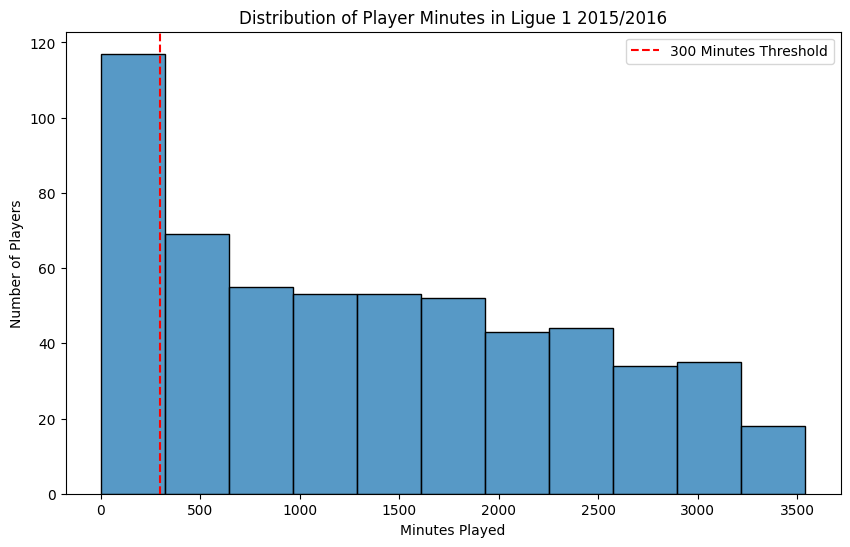

In [19]:
print(f"Number of players with at least 300 minutes: {len(filtered_players)}")
print(f"Total number of players: {len(players_df)}")
print(f"Percentage of players with at least 300 minutes: {len(filtered_players) / len(players_df) * 100:.2f}%")

# Histogram of player minutes
plt.figure(figsize=(10, 6))
sns.histplot(players_df['Minutes'], bins='auto', kde=False)
plt.axvline(300, color='red', linestyle='--', label='300 Minutes Threshold')
plt.title('Distribution of Player Minutes in Ligue 1 2015/2016')
plt.xlabel('Minutes Played')
plt.ylabel('Number of Players')
plt.legend()
plt.show()

In [22]:
unique_position_count = filtered_players.groupby('most_played_position').size()
unique_position_count

most_played_position
Center Attacking Midfield    21
Center Back                   1
Center Defensive Midfield    16
Center Forward               45
Goalkeeper                   35
Left Back                    43
Left Center Back             35
Left Center Forward           6
Left Center Midfield         22
Left Defensive Midfield      22
Left Midfield                13
Left Wing                    24
Right Back                   41
Right Center Back            38
Right Center Forward          8
Right Center Midfield        19
Right Defensive Midfield     23
Right Midfield               11
Right Wing                   37
dtype: int64

In [21]:
# Give a list of all positions played by players with at least 300 minutes
unique_positions = filtered_players['most_played_position'].unique().tolist()
unique_positions

['Left Wing',
 'Center Forward',
 'Right Center Back',
 'Left Center Back',
 'Left Center Midfield',
 'Left Back',
 'Goalkeeper',
 'Center Attacking Midfield',
 'Right Back',
 'Right Defensive Midfield',
 'Left Defensive Midfield',
 'Right Wing',
 'Right Center Forward',
 'Left Midfield',
 'Right Midfield',
 'Right Center Midfield',
 'Left Center Forward',
 'Center Defensive Midfield',
 'Center Back']

# Only take into account segments of players playing as center forwards

# Filter on midfielders with at least 300 minutes

In [19]:
filtered_player_ids = filtered_players['player_id']
mask = df_events['player_id'].isin(filtered_player_ids)
df_events_filtered = df_events[mask].copy()
df_events_filtered

,x,y,possession_kept,possession_length,chain_length,previous_deleted,match_id,period,player_id,type,...,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id,shot,goal
index,,,,,,,,,,,,,,,,,,,,,
8,37.6250,34.085,True,0,0,True,3829413,1,3026.0,Pass,...,Ground Pass,NaN,Carry,26.0750,28.305,NaN,131.0,3956.0,False,False
1797,26.0750,28.305,True,1,1,False,3829413,1,3956.0,Carry,...,None,NaN,Pass,25.6375,30.260,NaN,131.0,3956.0,False,False
9,25.6375,30.260,True,2,2,False,3829413,1,3956.0,Pass,...,Ground Pass,NaN,Carry,24.2375,45.220,NaN,131.0,3295.0,False,False
1798,24.2375,45.220,True,3,3,False,3829413,1,3295.0,Carry,...,None,NaN,Pass,27.7375,49.045,NaN,131.0,3295.0,False,False
10,27.7375,49.045,True,4,4,False,3829413,1,3295.0,Pass,...,Ground Pass,NaN,Pass,31.0625,38.080,NaN,131.0,3026.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2630,13.2125,30.685,True,15,1,False,3901263,2,40528.0,Carry,...,None,NaN,Pass,13.2125,30.685,NaN,2736.0,40528.0,False,False
977,13.2125,30.685,False,16,0,False,3901263,2,40528.0,Pass,...,High Pass,NaN,Carry,63.7000,31.365,1.0,134.0,40699.0,False,False
2631,63.7000,31.365,True,17,1,False,3901263,2,40699.0,Carry,...,None,1.0,Carry,66.9375,35.020,1.0,134.0,40699.0,False,False


## Apply ratings from the true model 16x12

In [ ]:
# Get necessary columns
df_events_filtered['shot'] = ~df_events_filtered['shot_outcome'].isna()
df_events_filtered['goal'] = df_events_filtered['shot_outcome'] == 'Goal'

# Apply ratings
df_events_filtered = xT_true_16x12.quantify_action_quality(df_events_filtered)
# Filter for positive xT actions
df_positive = df_events_filtered[df_events_filtered['action_xT'] > 0]
df_positive = df_positive.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
# df_positive_midfielders = df_positive[df_positive['main_position'] == 'midfielder']

In [ ]:
# df_positive_midfielders.head()

In [ ]:
# Aggregate xT ratings for midfielders
xT_ratings = df_positive.groupby('player_id').agg(
    xT_sum=('action_xT', 'sum'),
    action_count=('action_xT', 'count'),
    Minutes=('Minutes', 'first'),
    main_position=('main_position', 'first'),
).reset_index()
xT_ratings['xT_per_90'] = xT_ratings['xT_sum'] / xT_ratings['Minutes'] * 90
xT_ratings['Quartile'] = pd.qcut(xT_ratings['xT_per_90'], 4, labels=False) + 1
xT_ratings.head()

NameError: name 'df_positive_midfielders' is not defined

# Perform simulations

In [21]:
# Simulation parameters
N_bootstrap = 10_000
thetas = np.linspace(0.001, 0.005)

In [22]:
# Prepare data for bootstrapping
xT_ratings.sort_values('player_id', inplace=True)
original_quartiles = xT_ratings['Quartile'].values
original_ratings = xT_ratings['xT_per_90'].values
number_of_actions = xT_ratings['action_count'].values
number_of_minutes = xT_ratings['Minutes'].values
n_players = len(original_ratings)

## Find cut-off point error distribution

The student t distribution is most suitable because of the more heavy tails. We would like the relationship between the maximal errror and the average error to be the same. Therefore, we will now try to find the cut-off point to get this done. We can then rescale the distribution to have the correct maximal error.

In [35]:
# Mean error/max error
mean_max_ratio = 0.0158860

In [36]:
cut_off_points = np.linspace(0.001, 300, 2000)
mean_max_ratios = np.zeros(len(cut_off_points))

np.random.seed(42)

for i in tqdm(range(len(cut_off_points))):
    cut_off_value = cut_off_points[i]

    samples = np.random.standard_t(size = 1_000_000, df=1)
    samples[samples > cut_off_value] = cut_off_value
    samples[samples < -cut_off_value] = -cut_off_value
    
    mean_max_ratios[i] = np.abs(samples).mean()/np.abs(samples).max()

100%|██████████| 2000/2000 [02:57<00:00, 11.26it/s]


In [37]:
cut_off_factor = cut_off_points[np.argmin(np.abs(mean_max_ratios - mean_max_ratio))]
cut_off_factor

np.float64(263.5318874437218)

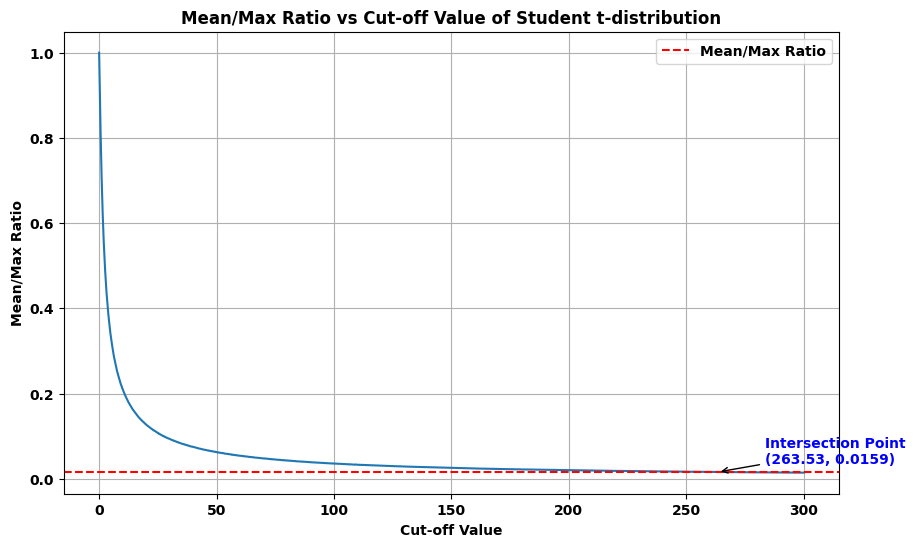

In [38]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(cut_off_points, mean_max_ratios)
plt.axhline(y=mean_max_ratio, color='r', linestyle='--', label='Mean/Max Ratio')
# Annotate intersecting point
intersection_idx = np.argmin(np.abs(mean_max_ratios - mean_max_ratio))
intersection_x = cut_off_points[intersection_idx]
intersection_y = mean_max_ratios[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.2f}, {intersection_y:.4f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x + 20, intersection_y + 0.02),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='blue')
plt.legend()
plt.title('Mean/Max Ratio vs Cut-off Value of Student t-distribution')
plt.xlabel('Cut-off Value')
plt.ylabel('Mean/Max Ratio')
plt.grid()
plt.show()


We can see that the cut-off point should be 269. We will now plot the resulting distribution.

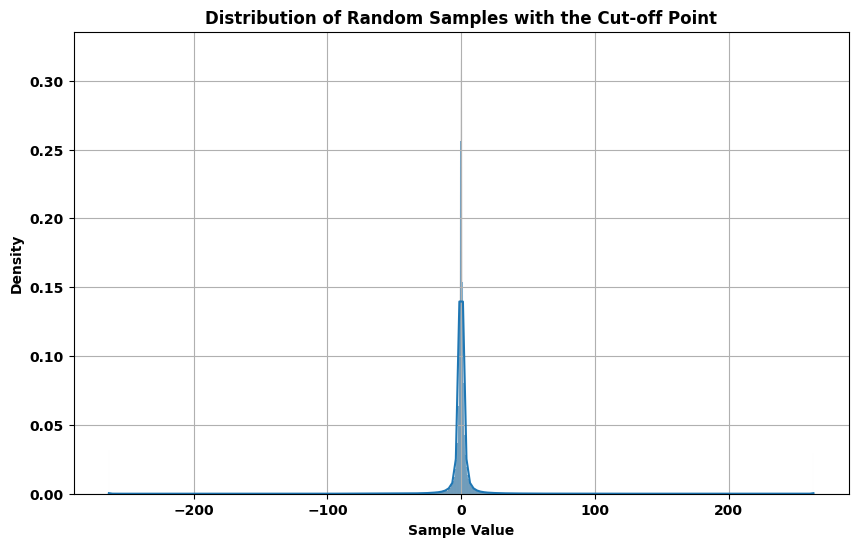

The mean/max ratio is 0.015938353036344416 with max error 263.5318874437218.


In [39]:
np.random.seed(42)

samples = np.random.standard_t(size = 1_000_000, df=1)
samples[samples > cut_off_factor] = cut_off_factor
samples[samples < -cut_off_factor] = -cut_off_factor

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, stat='density')
plt.title('Distribution of Random Samples with the Cut-off Point')
plt.xlabel('Sample Value')
plt.ylabel('Density')
plt.grid()
plt.show()

print(f'The mean/max ratio is {np.abs(samples).mean()/np.abs(samples).max()} with max error {np.abs(samples).max()}.')

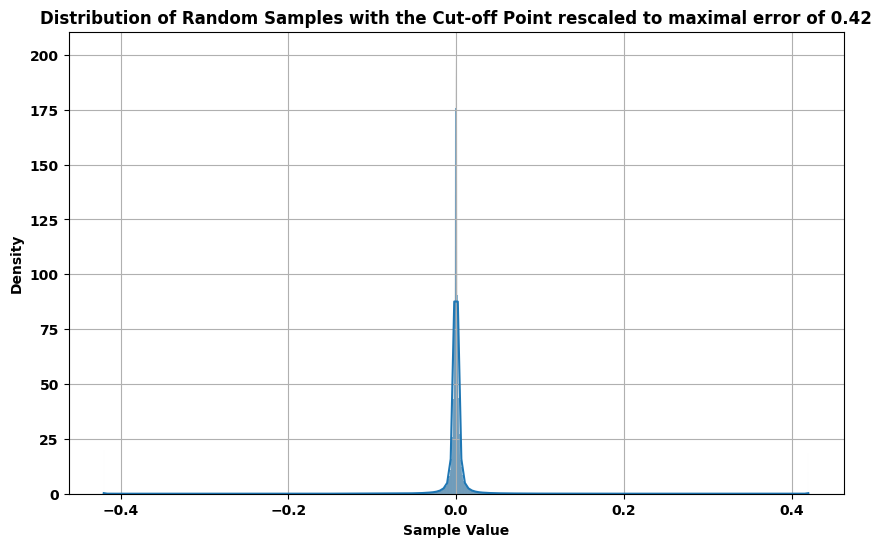

The mean/max ratio is 0.015938353036344433 with max error 0.42.


In [40]:
np.random.seed(42)

max_error = 0.42

samples = np.random.standard_t(size = 1_000_000, df=1) * max_error / cut_off_factor
samples[samples > max_error] = max_error
samples[samples < -max_error] = -max_error

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, stat='density')
plt.title('Distribution of Random Samples with the Cut-off Point rescaled to maximal error of 0.42')
plt.xlabel('Sample Value')
plt.ylabel('Density')
plt.grid()
plt.show()

print(f'The mean/max ratio is {np.abs(samples).mean()/np.abs(samples).max()} with max error {np.abs(samples).max()}.')

# Perform simulations on full in-game set of players

In [17]:
all_xT_ratings = df_positive.groupby('player_id').agg(
    xT_sum=('action_xT', 'sum'),
    action_count=('action_xT', 'count'),
    Minutes=('Minutes', 'first'),
    main_position=('main_position', 'first'),
).reset_index()
all_xT_ratings['xT_per_90'] = all_xT_ratings['xT_sum'] / all_xT_ratings['Minutes'] * 90
all_xT_ratings['Quartile'] = pd.qcut(all_xT_ratings['xT_per_90'], 4, labels=False) + 1
field_player_xT_ratings = all_xT_ratings[all_xT_ratings['main_position'] != 'Goalkeeper'].copy()
field_player_xT_ratings.head()

,player_id,xT_sum,action_count,Minutes,main_position,xT_per_90,Quartile
0,2954.0,0.725121,124,349,midfielder,0.186994,3
1,2988.0,1.403322,102,332,attacker,0.380419,4
2,2999.0,0.522738,275,415,defender,0.113365,2
3,3009.0,0.765843,81,415,attacker,0.166086,3
4,3026.0,0.445377,144,321,defender,0.124872,3


In [16]:
# Prepare data for bootstrapping
field_player_xT_ratings.sort_values('player_id', inplace=True)
original_quartiles = field_player_xT_ratings['Quartile'].values
original_ratings = field_player_xT_ratings['xT_per_90'].values
number_of_actions = field_player_xT_ratings['action_count'].values
number_of_minutes = field_player_xT_ratings['Minutes'].values
n_players = len(original_ratings)

## Quickly simulate for general range of values

In [54]:
# Define range of max errors and number of bootstraps
N_bootstrap = 10_000
max_errors = np.linspace(0.1, 0.01, 50)

# Set seed for repeatability
np.random.seed(42)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(max_errors)))

for i_max_error in tqdm(range(len(max_errors))):
    max_error = max_errors[i_max_error]
    for i_bootstrap in range(N_bootstrap):

        # Get the ratings
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            # Sample the errors
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_error / cut_off_factor
            samples[samples > max_error] = max_error
            samples[samples < -max_error] = -max_error

            # Calculate the new rating
            # Rescale the samples to per 90 minutes
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        
        # Calculate the new quartiles
        # Note: pd.qcut returns 0-based indices, so we add 1 to make it 1-based
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_max_error] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 14).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 50/50 [26:40<00:00, 32.00s/it]


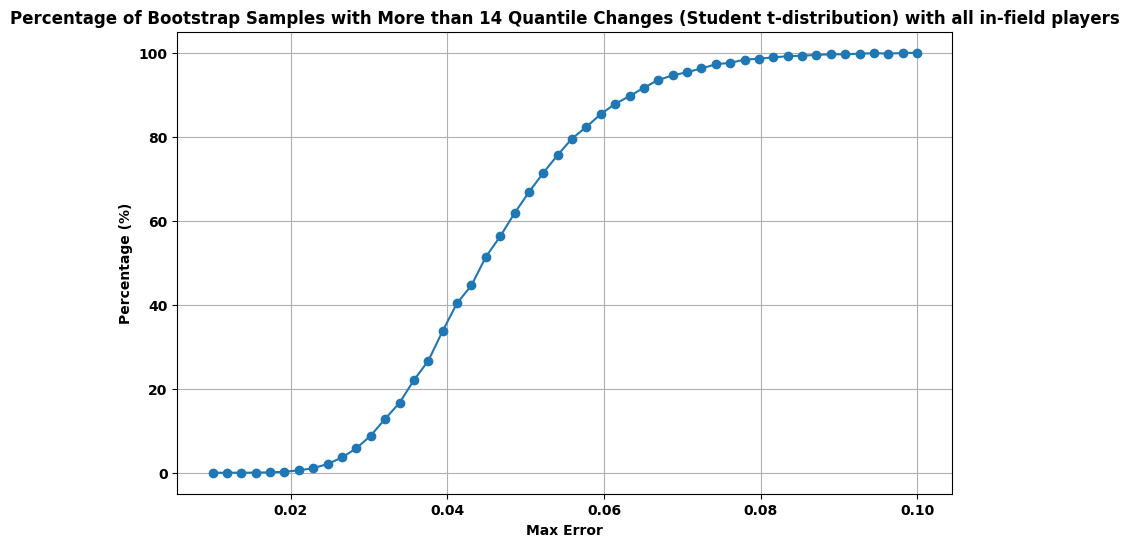

In [55]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o')
plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution) with all in-field players')
plt.xlabel('Max Error')
plt.ylabel('Percentage (%)')
plt.grid()
plt.show()

## Thoroughly simulate for specific range of values

In [56]:
# Define range of max errors and number of bootstraps
N_bootstrap = 100_000
max_errors = np.linspace(0.02, 0.035, 50)

# Set seed for repeatability
np.random.seed(42)

# Initialize arrays to store bootstrap results
bootstrap_quartile_changes_student = np.zeros((N_bootstrap, len(max_errors)))

for i_max_error in tqdm(range(len(max_errors))):
    max_error = max_errors[i_max_error]
    for i_bootstrap in range(N_bootstrap):

        # Get the ratings
        bootstrap_ratings = original_ratings.copy()

        for i_player in range(n_players):
            # Sample the errors
            samples = np.random.standard_t(size = number_of_actions[i_player], df=1) * max_error / cut_off_factor
            samples[samples > max_error] = max_error
            samples[samples < -max_error] = -max_error

            # Calculate the new rating
            # Rescale the samples to per 90 minutes
            bootstrap_ratings[i_player] += samples.sum()/number_of_minutes[i_player] * 90
        
        # Calculate the new quartiles
        # Note: pd.qcut returns 0-based indices, so we add 1 to make it 1-based
        bootstrap_quartiles = pd.qcut(bootstrap_ratings, 4, labels=False) + 1
        bootstrap_quartile_changes_student[i_bootstrap, i_max_error] = np.sum(bootstrap_quartiles != original_quartiles)

# Calculate the percentage of bootstrap samples with more than 4 quantile changes
N_wrong_student = (bootstrap_quartile_changes_student > 14).sum(axis=0)
percent_wrong_student = N_wrong_student / N_bootstrap * 100


100%|██████████| 50/50 [6:45:06<00:00, 486.12s/it]   


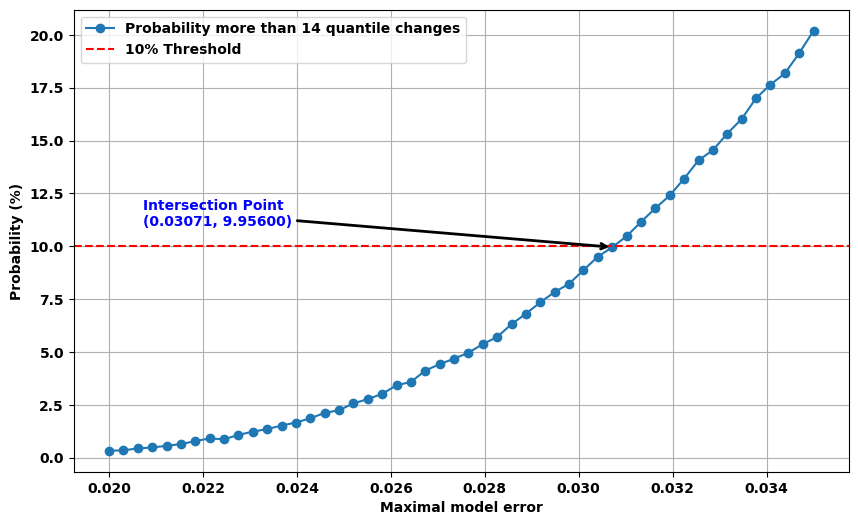

In [63]:
# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(max_errors, percent_wrong_student, marker='o', label='Probability more than 14 quantile changes')

# Add a line to indicate 5%
plt.axhline(y=10, color='r', linestyle='--', label='10% Threshold')

# Annotate the intersection point
intersection_idx = np.argwhere(percent_wrong_student < 10).max()
intersection_x = max_errors[intersection_idx]
intersection_y = percent_wrong_student[intersection_idx]
plt.annotate(f'Intersection Point\n({intersection_x:.5f}, {intersection_y:.5f})',
             xy=(intersection_x, intersection_y), xytext=(intersection_x - 0.01, intersection_y + 1),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=2.0),
             fontsize=10, color='blue')

# plt.title('Percentage of Bootstrap Samples with More than 14 Quantile Changes (Student t-distribution)')
plt.xlabel('Maximal model error')
plt.ylabel('Probability (%)')
plt.legend()
plt.grid()
plt.show()

In [61]:
print(intersection_x, intersection_y)

0.030714285714285715 9.956
